In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from unsflow.utils.plot_styles import *

In [2]:
simFiles = [
    '../results/rotor_stator_gap_0.0.pkl',
    '../results/rotor_stator_gap_5.0.pkl',
]

labels=[
    '0.0',
    '+ \infty',
]

refFiles = [
    'spakovszky_results/rotor_stator_dx0.csv',
    'spakovszky_results/rotor_dx_5.csv',
    'spakovszky_results/stator_dx_5.csv',
]

In [3]:
simData = []
for sim in simFiles:
    with open(sim, 'rb') as f:
        simData.append(pickle.load(f))

refData = []
for ref in refFiles:
    refData.append(pd.read_csv(ref))

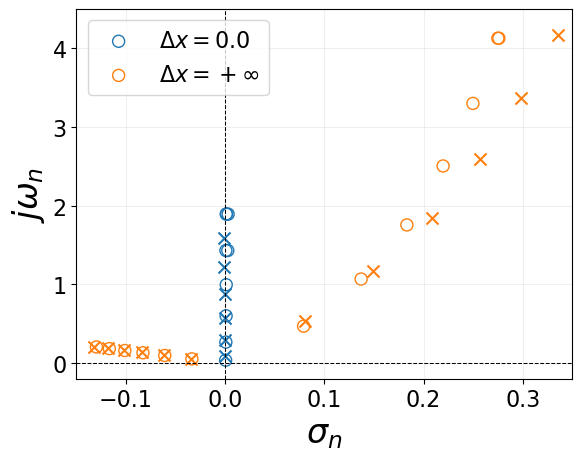

In [4]:
ms = 75

for ii,sim in enumerate(simData):
    for n in range(1,7):
        if n==1:
            plt.scatter(sim.poles_dict[n].real, -sim.poles_dict[n].imag, edgecolors='C%i' %ii, c='none', s=ms, label=r'$\Delta x = %s$' %labels[ii])
        else:
            plt.scatter(sim.poles_dict[n].real, -sim.poles_dict[n].imag, edgecolors='C%i' %ii, c='none', s=ms)


plt.scatter(refData[0]['x'], refData[0][' y'], marker='x', c='C0', s=ms)
plt.scatter(refData[1]['x'], refData[1][' y'], marker='x', c='C1', s=ms)
plt.scatter(refData[2]['x'], refData[2][' y'], marker='x', c='C1', s=ms)

plt.axhline(0, color='black', ls='--', lw=0.75)
plt.axvline(0, color='black', ls='--', lw=0.75)

plt.xlabel(r'$\sigma_{n}$')
plt.ylabel(r'$j \omega_{n}$')
plt.grid(alpha=0.2)        
plt.legend(loc='upper left')
plt.xlim([-0.15, 0.35])
plt.ylim([-0.2, 4.5])
plt.savefig('rotor_stator_poles_comparison_spakovszky.pdf', bbox_inches='tight')